### Q5(a) - Create 5x5 Gaussian Kernel

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------------
# Q5(a) - Create 5x5 Gaussian Kernel
# -----------------------------------

def gaussian_kernel(size, sigma):
    half = size // 2
    x, y = np.meshgrid(
        np.arange(-half, half + 1),
        np.arange(-half, half + 1)
    )

    kernel = (1 / (2 * np.pi * sigma**2)) * \
             np.exp(-(x**2 + y**2) / (2 * sigma**2))

    kernel = kernel / np.sum(kernel)  # normalize
    return kernel

sigma = 2
kernel_5x5 = gaussian_kernel(5, sigma)

print("Q5(a) - 5x5 Gaussian Kernel:")
print(kernel_5x5)
print("Sum:", kernel_5x5.sum())



Q5(a) - 5x5 Gaussian Kernel:
[[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]
Sum: 0.9999999999999998


### Q5(b) - 3D Surface Plot (51x51)

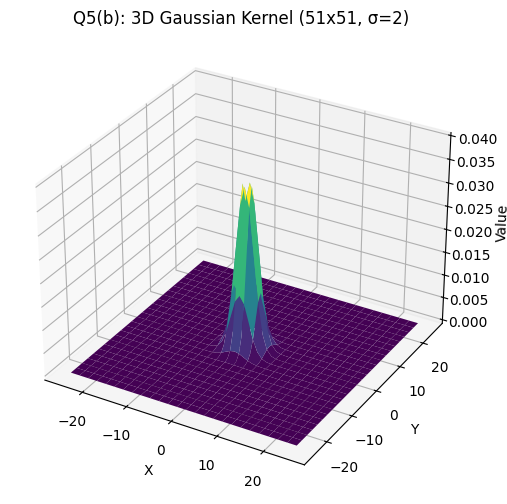

In [3]:
# -----------------------------------
# Q5(b) - 3D Surface Plot (51x51)
# -----------------------------------

kernel_51 = gaussian_kernel(51, sigma)

half = 51 // 2
X, Y = np.meshgrid(
    np.arange(-half, half + 1),
    np.arange(-half, half + 1)
)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, kernel_51, cmap='viridis')

ax.set_title('Q5(b): 3D Gaussian Kernel (51x51, σ=2)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Value')

plt.show()


# -----------------------------------
# Load Grayscale Image (Runway)
# -----------------------------------

img = cv.imread('runway.png', cv.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image not found. Check path.")

### Q5(c) - Manual Gaussian Smoothing

In [4]:
# -----------------------------------
# Q5(c) - Manual Gaussian Smoothing
# -----------------------------------

def manual_convolution(image, kernel):
    kh, kw = kernel.shape
    pad = kh // 2

    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='reflect')
    output = np.zeros_like(image, dtype=np.float64)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

smoothed_manual = manual_convolution(img, kernel_5x5)

### Q5(d) - OpenCV GaussianBlur

In [5]:
# -----------------------------------
# Q5(d) - OpenCV GaussianBlur
# -----------------------------------

smoothed_cv = cv.GaussianBlur(img, (5,5), sigmaX=2)

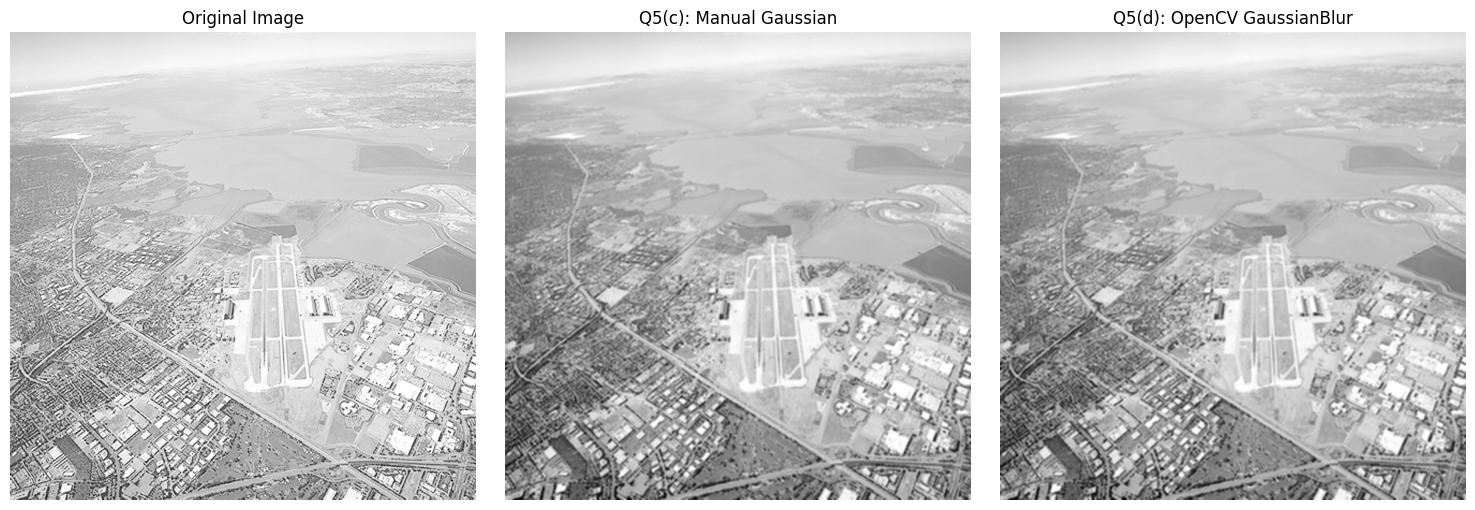

In [6]:
# -----------------------------------
# Display Results
# -----------------------------------

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(smoothed_manual, cmap='gray')
plt.title('Q5(c): Manual Gaussian')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(smoothed_cv, cmap='gray')
plt.title('Q5(d): OpenCV GaussianBlur')
plt.axis('off')

plt.tight_layout()
plt.show()


Max Difference: 1
Mean Difference: 0.500148737431687


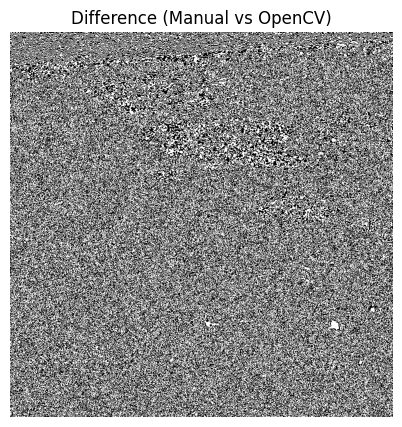

In [7]:
# -----------------------------------
# Difference Analysis
# -----------------------------------

diff = np.abs(smoothed_manual.astype(np.int16) - smoothed_cv.astype(np.int16))

print("Max Difference:", diff.max())
print("Mean Difference:", diff.mean())

plt.figure(figsize=(5,5))
plt.imshow(diff, cmap='gray')
plt.title('Difference (Manual vs OpenCV)')
plt.axis('off')
plt.show()

#### Q5(a)

A 5×5 Gaussian kernel was generated using the Gaussian function with σ = 2. The kernel was normalized so that the sum of all values equals 1, ensuring that the overall brightness of the image remains unchanged after filtering.

Q5(b)

A 51×51 Gaussian kernel was visualized as a 3D surface plot. The plot shows a smooth peak at the center with values gradually decreasing toward the edges. This confirms the symmetric and smooth nature of the Gaussian function.

Q5(c)

The manually computed Gaussian kernel was applied to the grayscale image using convolution. The result shows smoother intensity variations and reduced noise, although some edges become slightly blurred.

Q5(d)

Gaussian smoothing was also applied using OpenCV’s GaussianBlur() function. The result is very similar to the manually computed output. Small differences occur due to implementation details such as padding and rounding.